## Регулярные выражения

#### Поиск образцов текста

In [118]:
def is_phone_number(text):
    if len(text) != 12:
        return False
    for i in range(3):
        if not text[i].isdecimal():
            return False
    if text[3] != '-':
        return False
    for i in range(4,7):
        if not text[i].isdecimal():
            return False
    if text[7] != '-':
        return False
    for i in range(8,12):
        if not text[i].isdecimal():
            return False
    return True

In [119]:
print(is_phone_number('111-222-3333'))

True


#### Поиск образцов текста во всем тексте

In [120]:
mytext = '''Мой домашний номер телефона - 111-222-3333, рабочий номер телефона - 222-333-4444 '''

In [121]:
for i in range(len(mytext)):
    text = mytext[i:i+12]
    if is_phone_number(text):
        print('Найден номер телефона: ' + text)
print('Завершено')

Найден номер телефона: 111-222-3333
Найден номер телефона: 222-333-4444
Завершено


#### Регулярные выражения

Регулярные выражения позволяют задавать шаблон искомого текста.

Используя регулярные выражения  вы указывается правила для множества возможных строк, которые вы хотите проверить.

С помощью регулярных выражений вы можете:
- задавать вопросы вида: «Соответствует ли эта строка шаблону?» или «Совпадает ли шаблон где-нибудь с этой строкой?»
- изменять строку 
- разбивать ее на части различными способами.


##### Создание объектов Regex

In [122]:
import re

Вызов метода `re.compile()` с передачей ему строкового значения, представляющего регулярное выражение, возвращает объект соответствующего регулярного выражения (**объект Regex**).


In [123]:
rphone_num = re.compile (r'\d\d\d-\d\d\d-\d\d\d\d')
print(rphone_num)

re.compile('\\d\\d\\d-\\d\\d\\d-\\d\\d\\d\\d')


rphone_num содержится объект Regex.

##### Поиск соответствий объектам Regex

Метод `search()` объекта **Regex** ищет в переданной ему строке любые совпадения с регулярным выражением.

В случае отсутствия в строке совпадений с регулярным выражением он возвращает значение **None**. Если совпадения обнаружены, то метод `search()` возвращает объект **Match**. 

Объекты Match имеют метод `group()`, который возвращает найденные соответствия шаблону.

In [124]:
mres = rphone_num.search('Мой номер: 111-222-3333.')
print(mres)

<re.Match object; span=(11, 23), match='111-222-3333'>


In [125]:
print(mres.group())

111-222-3333


##### Пошаговая процедура поиска соответствий регулярному выражению:

1. Импорт модуля regex с помощью инструкции import re.
2. Создание объекта Regex с помощью функции re.compile(). 
3. Передача строки, в которой хотим выполнить поиск, методу search() обьекта Regex. Этот метод возвращает объект Match. 
4. Вызов метода group() объекта Match, который вернет строку, содержащую фактический найденный текст, соответствующий данному регулярному выражению.


#### Шаблоны регулярных выражений

##### Создание групп с помощью круглых скобок

Добавление круглых скобок приводит к созданию групп в регулярных выражениях: 
`(\d\d\d) -(\d\d\d-\d\d\d\d)`. 

Первый набор круглых скобок в строке регулярного выражения будет группой 1. Второй набор будет группой 2. 

In [126]:
import re
r_number = re.compile(r'(\d\d\d)-(\d\d\d-\d\d\d\d)')
res = r_number.search('Мой номер: 111-222-3333.')
print(res.group())
print(res.group(1))
print(res.group(2))
#print(res.group(3))

111-222-3333
111
222-3333


In [127]:
print(res.groups())

('111', '222-3333')


In [128]:
code, number = res.groups()
print(code, number)

111 222-3333


In [129]:
r_number = re.compile(r'(\(\d\d\d\))-(\d\d\d-\d\d\d\d)')
res = r_number.search('Мой номер: (111)-222-3333.')
print(res.groups())

('(111)', '222-3333')


##### Выбор альтернативных групп с помощью канала

Символ `|` называется каналом.

Например, регулярному выражению `r'Batman|Terminator'` будут соответствовать как строка 'Batman', так и строка 'Terminator'.

In [130]:
hero = re.compile(r'Batman|Terminator')
res = hero.search('Batman and Terminator')
print(res.group())

Batman


In [131]:
hero = re.compile(r'Batman|Terminator')
res = hero.search('Terminator and Batman')
print(res.group())

Terminator


In [132]:
bat = re.compile(r'Bat(man|woman|bat|copter)')
res = bat.search('Batwoman Batman hero')
print(res.group())
print(res.group(0))
print(res.group(1))

Batwoman
Batwoman
woman


##### Указание необязательной группы символов с помощью вопросительного знака


Символ `?` указывает на то, что предшествующая ему группа является необязательной частью поискового шаблона. 

Регулярному выражению будет соответствовать текст, в котором подстрока, стоящая перед знаком вопроса либо вообще не встречается, либо встречается только один раз. 

In [133]:
bat = re.compile(r'Bat(wo)?man')
res1 = bat.search('The adventures of Batman')
print(res1.group())
res2 = bat.search('The adventures of Batwoman')
print(res2.group())
#res3 = bat.search('The adventures of Batwowoman')
#print(res3.group())

Batman
Batwoman


In [134]:
r_number = re.compile(r'(\d\d\d-)?\d\d\d-\d\d\d\d')
res1 = r_number.search('Мой номер: 111-222-3333.')
print(res1.group())

res2 = r_number.search('Мой номер: 222-3333.')
print(res2.group())

111-222-3333
222-3333


##### Указание соответствия группе символов, повторяющейся нуль или несколько раз, с помощью `*`


Символ * ("звездочка") означает "совпадение с нулевым или большим количеством экземпляров".

In [135]:
bat = re.compile(r'Bat(wo)*man')
res1 = bat.search('The adventures of Batman')
print(res1.group())
res2 = bat.search('The adventures of Batwoman')
print(res2.group())
res3 = bat.search('The adventures of Batwowowowowoman')
print(res3.group())

Batman
Batwoman
Batwowowowowoman


##### Указание соответствия одному или нескольким повторениям группы с помощью `+`

Символ + ("плюс") означает "совпадение с одиночным или большим количеством экземпляров"

In [136]:
bat = re.compile(r'Bat(wo)+man')
res1 = bat.search('The adventures of Batwoman')
print(res1.group())
res2 = bat.search('The adventures of Batwowowoman')
print(res2.group())
#res3 = bat.search('The adventures of Batman')
#print(res3.group())

Batwoman
Batwowowoman


##### Указание соответствия определенному количеству повторений группы с помощью фигурных скобок


Регулярному выражению `(На){3}` будет соответствовать строка `'НаНаНа'`, но не строка `'НаНа'`.

Можем указать диапазон, записав в фигурных скобках значения минимального и максимального числа допустимых повторений, разделенные запятой. Например, выражению `(На){3,5}` будут соответствовать строки `'НаНаНа'`, `'НаНаНаНа'` и `'НаНаНаНаНа'`.

Регулярному выражению `(На){3,}` будут соответствовать три и более экземпляров группы `(На)`, тогда как регулярному выражению `(На){, 5}`будут соответствовать от нуля до пяти экземпляров.

In [137]:
hahaha = re.compile(r'(Ha){3}')
res1 = hahaha.search('haHaHaHa - words')
print(res1.group())
#res2 = hahaha.search('haHaHa - words')
#print(res2.group())

HaHaHa


##### Жадный и нежадный виды поиска

Регулярные выражения Python по умолчанию являются жадными, т.е. в неоднозначных ситуациях они будут пытаться соответствовать как можно более длинной строке. 

In [138]:
rha = re.compile(r'(Ha){3,5}')
res1 = rha.search('HaHaHaHaHaHaHa')
res1.group()

'HaHaHaHaHa'

Нежадная версия фигурных скобок, которая пытается соответствовать самой короткой из возможных строк, характеризуется наличием вопросительного знака сразу за закрывающей фигурной скобкой.

In [139]:
ha = re.compile(r'(Ha){3,5}?')
res = ha.search('HaHaHaHaHaHaHa')
res.group()

'HaHaHa'

#### Метод findall()

Метод `search()` возвращает объект `Match` первого совпадения, найденного в тестируемой строке.

In [140]:
phone = re.compile(r'\d\d\d-\d\d\d-\d\d\d\d')
res = phone.search('Сотовый: 111-222-3333, рабочий: 444-555-6666')
res.group()

'111-222-3333'

Метод `findall()` возвращает строки каждого из найденных совпадений. 

In [141]:
phone = re.compile(r'\d\d\d-\d\d\d-\d\d\d\d')
res = phone.findall('Сотовый: 111-222-3333, рабочий: 444-555-6666')
print(res)

['111-222-3333', '444-555-6666']


В случае наличия групп в регулярном выражении метод `findall()` возвратит **список кортежей**.  

Каждый кортеж представляет найденное соответствие, а его элементы — совпавшие строки для каждой группы в регулярном выражении. 

In [142]:
phone = re.compile(r'(\d\d\d)-(\d\d\d)-(\d\d\d\d)')
res = phone.findall('Сотовый: 111-222-3333, рабочий: 444-555-6666')
print(res)


[('111', '222', '3333'), ('444', '555', '6666')]


In [143]:
phone = re.compile(r'(\d\d\d)-\d\d\d-\d\d\d\d')
res = phone.findall('Сотовый: 111-222-3333, рабочий: 444-555-6666')
print(res)

['111', '444']


#### Символьные классы

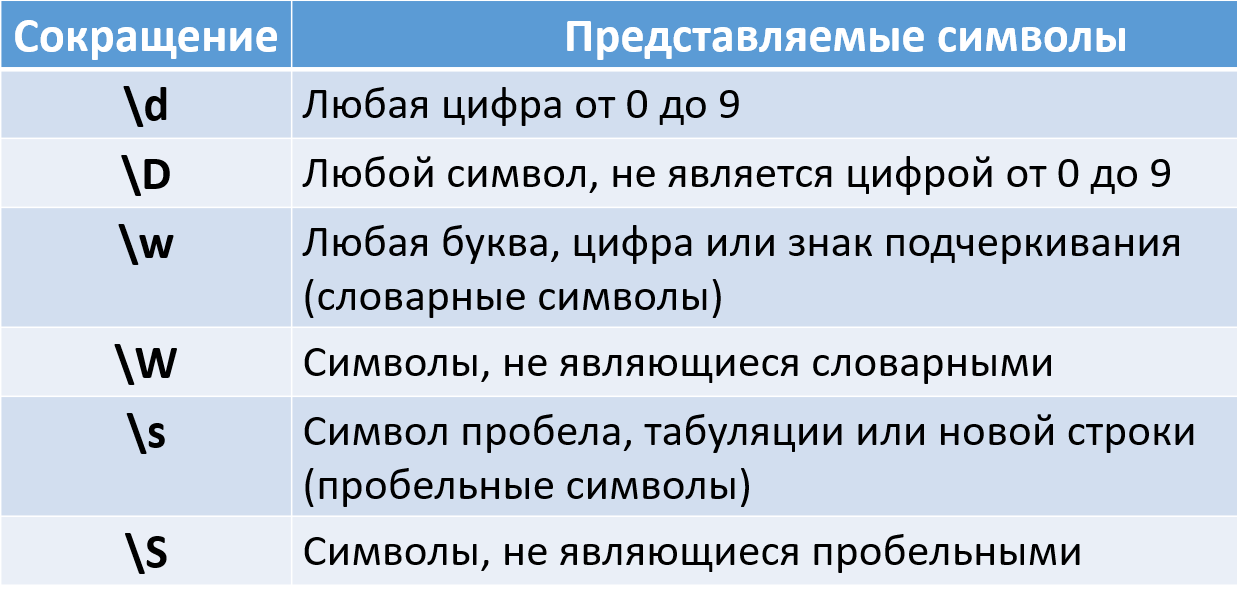

#### Символьные классы

Символьные классы (классы символов) удобно использовать для компактной записи регулярных выражений. 

Классу символов [0-5] будет соответствовать любая одиночная цифра в диапазоне от 0 до 5; такая запись гораздо короче, чем запись (0|1|2|3|4|5).

In [144]:
import re

x = re.compile(r'\d+\s\w+')
res = x.findall('12 m, 67 df, 1 errrr, rt34, 4 1 rr eeac abcd 7')
print(res)
                

['12 m', '67 df', '1 errrr', '4 1']


Сокращенные символьные классы (\d, \w, \s и т.д.) иногда оказываются слишком широкими.

Можем создать собственный символьный класс, используя квадратные скобки. 

Например, `[aeiouAEIOU]`.

In [145]:
y = re.compile(r'[aeiouAEIOU]')
res = y.findall('abcdefAgBxUEyzESatu')
print(res)

['a', 'e', 'A', 'U', 'E', 'E', 'a', 'u']


В классы также можно включать диапазоны букв и цифр, используя дефис. Например, класс `[a-zA-Z0-9]`.

В пределах квадратных скобок обычные символы регулярных выражений не интерпретируются как таковые. 

Это означает, что перед символами .,*,?, ( и ) не следует ставить символ обратной косой черты. 

Например, класс `[0-5.]` 

In [149]:
y = re.compile(r'[0-5.]')
res = y.findall('ab78cde2fAgBx3UEy.345z.ESa98tu')
print(res)

['2', '3', '.', '3', '4', '5', '.']


С помощью символа "крышка", или **циркумфлекс** (`^`) можно создать инвертированный символьный класс. 

Инвертированному символьному классу будет соответствовать любой символ, не принадлежащий исходному классу. 


In [150]:
x = re.compile(r'[^aeiouAEIOU]')
res = x.findall('effaueaprtySDrFau5fg212kgf')
print(res)

['f', 'f', 'p', 'r', 't', 'y', 'S', 'D', 'r', 'F', '5', 'f', 'g', '2', '1', '2', 'k', 'g', 'f']


Символ ^ ("крышка") в начале регулярного выражения используется для указания того, что соответствие регулярному выражению должно находиться в начале тестируемого текста. 

Знак доллара ($) в конце регулярного выражения используется для указания того, что строка должна заканчиваться данным шаблоном регулярного выражения. 

Использовать символы ^ и $ можно совместно, для того чтобы показать: данному регулярному выражению должна соответствовать вся строка, т.е. совпадения с ним лишь какой-то подстроки будет недостаточно.

Регулярному выражению `r'^Hello'` будут соответствовать строки, начинающиеся со слова 'Hello'. 

In [151]:
h = re.compile(r'^Hello')
res = h.findall('Hello world HelloWorld Hello hello')
print(res)
print(h.search('Hello world HelloWorld Hello hello'))
res = h.findall('Helo world HelloWorld Hello hello')
print(res)

['Hello']
<re.Match object; span=(0, 5), match='Hello'>
[]


Регулярному выражению `r'\d$'` будут соответствовать строки, заканчивающиеся любой цифрой в диапазоне от 0 до 9. 

In [152]:
n = re.compile(r'\d$')
res = n.search('Number 23')
print(res)

<re.Match object; span=(8, 9), match='3'>


In [153]:
n = re.compile(r'\d$')
res = n.search('Number 23')
print(res == None)

False


Регулярному выражению `r'^\d+$'` будут соответствовать строки, которые начинаются и заканчиваются одной или несколькими цифрами. 


In [154]:
nn = re.compile(r'^\d+$')
res = nn.search('23vcdvdvcv56')
print(res)

None


In [155]:
nn = re.compile(r'^\d+$')
res = nn.search('237477456')
print(res)

<re.Match object; span=(0, 9), match='237477456'>


#### Групповой символ

Символ `. `("точка") в регулярных выражениях называется групповым символом и представляет собой сокращенную форму записи символьного класса, совпадающего с любым одиночным символом, за исключением символа новой строки. 

In [156]:
t = re.compile(r'.тут')
res = t.findall('тут')
print(res)

[]


In [159]:
t = re.compile(r'.тут')
res = t.findall('тут     fgfg gктут .тут   ктут =тут')
print(res)

['ктут', '.тут', 'ктут', '=тут']


In [ ]:
res = t.findall('тут')
print(res)

Если хотим искать соответствие самой точке, то в регулярном выражении ей должен предшествовать символ обратной косой черты: \

#### Указание соответствия любому тексту с помощью комбинации "точка-звездочка"


Иногда желательно, чтобы регулярному выражению соответствовало все и вся. 

Пусть, например, хотим найти совпадение со строкой 'First Name:', за которой следует любой текст, за которым следует строка 'Last Name: ', а за ней — вновь любой текст. 

Для представления этого "любого текста" можно использовать комбинацию "точка-звездочка" `(.*)`. 

In [160]:
name = re.compile(r'Имя: (.*) Фамилия: (.*)')
res = name.search('Имя: Елена Фамилия: Сидорова')
res.group()

'Имя: Елена Фамилия: Сидорова'

In [161]:
res.group(1)

'Елена'

In [162]:
res.group(2)

'Сидорова'

Комбинация `.*` работает в режиме жадного поиска.


Для работы в нежадной манере, дополним ее  `.*?`. 

In [163]:
r = re.compile(r'<.*?>')
res = r.search('<Button-1>Button-2>')
res.group()

'<Button-1>'

In [164]:
r = re.compile(r'<.*>')
res = r.search('<Button-1>Button-2>')
res.group()

'<Button-1>Button-2>'

#### Указание соответствия символам новой строки с помощью точки

Комбинации "точка-звездочка" будет соответствовать все, за исключением символа новой строки. 
Передав методу `re.compile()` при его вызове константу `re.DOTALL` в качестве второго аргумента, можно установить режим, при котором точке соответствует также символ новой строки.


In [165]:
line = re.compile(r'.*')
res = line.search('Привет. \n Как дела? \n Как работа?')
print(res)
res.group()

<re.Match object; span=(0, 8), match='Привет. '>


'Привет. '

In [166]:
line = re.compile(r'.*',re.DOTALL)
res = line.search('Привет. \n Как дела? \n Как работа?')
print(res)
res.group()

<re.Match object; span=(0, 33), match='Привет. \n Как дела? \n Как работа?'>


'Привет. \n Как дела? \n Как работа?'

#### Символы регулярных выражений

| Символ | Значение |
| :--- | :---|
| `?` | соответствует отсутствию или одиночному вхождению предшествующей группы |
| `*` | соответствует отсутствию или произвольному количеству вхождений предшествующей группы |
|`+`|соответствует одиночному или большему количеству вхождений предшествующей группы|
|`{n}`|соответствует в точности `n` вхождениям предшествующей группы|
|`{n,}`|соответствует `n` или более вхождениям предшествующей группы|
|`{,m}`|соответствует отсутствию или вплоть до `m` вхождений предшествующей группы|
|`{n,m}`|соответствует не менее чем `n` и не более чем `m` вхождениям предшествующей группы|
|`{n,m}? *? +?`|выполняет нежадный поиск вхождений предшествующей группы|
|`^spam`|означает, что строка должна начинаться символами spam|
|`spam$`|означает, что строка должна заканчивайся символами spam|
|`.`|соответствует любому символу, за исключением символа новой строки|
|`\d`  `\w`  `\s`|совпадают с одиночным цифровым, словарным и пробельным символами соответственно|
|`\D` `\W` `\S`|совпадает с произвольным одиночным символом, не являющимся цифровым, словарным и пробельным соответственно|
|`[аbс]`|совпадает с любым одиночным символом из числа тex, которые указаны в квадратных скобках (например, a, b или с)|
|`[^abc]`|совпадает с любым одиночным символом, не относящимся к числу тех, которые указаны в квадратных скобках|




#### Игнорирование регистра при поиске соответствий

In [167]:
r = re.compile(r'hello')
res = r.search('Hello hello, Hello')
print(res)
res.group()

<re.Match object; span=(6, 11), match='hello'>


'hello'

In [168]:
r = re.compile(r'hello',re.I)
res = r.search('Hello hello, Hello')
print(res)
res.group()

<re.Match object; span=(0, 5), match='Hello'>


'Hello'

#### Когда НЕ стоит использовать регулярные выражения

Регулярные выражения — мощный, но не универсальный инструмент. Для простых задач они избыточны и работают медленнее, чем встроенные строковые методы.

Проверка на наличие префикса:

Плохо: re.match('prefix', text)

Хорошо: text.startswith('prefix')

Проверка на наличие суффикса:

Плохо: re.search('suffix$', text)

Хорошо: text.endswith('suffix')

Простой поиск подстроки:

Плохо: re.search('substring', text)

Хорошо: 'substring' in text

Простая замена:

Плохо: re.sub('old', 'new', text)

Хорошо: text.replace('old', 'new')

Разделение по одному символу:

Плохо: re.split(',', text)

Хорошо: text.split(',')

**Правило:**
 
Если задачу можно решить простым и читаемым строковым методом, используйте его. Он будет быстрее и понятнее для других разработчиков. Регулярные выражения — для сложных шаблонов.

#### ССЫЛКИ

[https://pythonru.com/osnovy/modul-re-dlja-reguljarnyh-vyrazhenij-v-python](https://pythonru.com/osnovy/modul-re-dlja-reguljarnyh-vyrazhenij-v-python)

[https://tproger.ru/translations/regular-expression-python](https://tproger.ru/translations/regular-expression-python)

[https://habr.com/ru/articles/956068/](https://habr.com/ru/articles/956068/)

[https://thecode.media/regulyarnye-vyrazheniya-v-python/](https://thecode.media/regulyarnye-vyrazheniya-v-python/)